>[Imports](#scrollTo=umAvin9Nkfoh)

>[File Imports](#scrollTo=WORabBz16j6j)

>[Task 2.1](#scrollTo=czlohpLTkv8A)

>[Task 2.2](#scrollTo=ljzMs4nxPB0c)

>>[Understanding Kmeans](#scrollTo=C6yKKxwLhId2)

>>[Task](#scrollTo=nZnX6G_YnB_D)

>[Task 2.3](#scrollTo=iwpIIvMroUmE)

>>[Understanding GMM](#scrollTo=xGiyITxppLKe)

>[Task 2.4](#scrollTo=3lV1-4-UCjFo)

>[Understanding Data](#scrollTo=UOLXJ6EqEOPT)

>>[Finding optimum number of clusters](#scrollTo=vNhAo2hPIL3U)

>>>[Solution 1 - Elbow method](#scrollTo=-g8JvbdXC6um)

>>>[Solution 2 - Silhouette Analysis](#scrollTo=mWTXGGscHmIk)

>>>[Summarization](#scrollTo=Xw3OGTZ5JUmL)

>>[GMM plot](#scrollTo=yQKNJ-5ZLLYN)



# Imports

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

#File Imports

In [ ]:
# Load the datasets
irisData = np.load('/content/Iris_data.npy')
irisLabels = np.load('/content/Iris_labels.npy')
print(irisData.shape)

#Data Structuring
sepalLength = [k[0] for k in irisData]
sepalWidth = [k[1] for k in irisData]
petalLength = [k[2] for k in irisData]
petalWidth = [k[3] for k in irisData]

(150, 4)


In [ ]:
test_data2_4 = np.load('/content/task2_4.npy')
print(test_data2_4.shape)
print(test_data2_4)

#Data structuring
test_data_X1 = [i[0] for i in test_data2_4]
test_data_X2 = [i[1] for i in test_data2_4]
test_data_X3 = [i[2] for i in test_data2_4]
test_data_X4 = [i[3] for i in test_data2_4]
test_data_X5 = [i[4] for i in test_data2_4]
test_data_X6 = [i[5] for i in test_data2_4]
test_data_X7 = [i[6] for i in test_data2_4]
test_data_X8 = [i[7] for i in test_data2_4]
test_data_X9 = [i[8] for i in test_data2_4]
test_data_X10 = [i[9] for i in test_data2_4]

(100, 10)
[[ -1.80398981  -4.09512605  -5.0253188    7.36569809   2.42258743
    5.29189383  -6.74486404  -9.30130833  -0.20340057  -2.821411  ]
 [  0.62631796  -4.25405505  -0.3319475  -10.46678667  -0.04903716
    3.46861606  -2.62423323  -4.89544881  -8.86515986   0.96944955]
 [  6.62214156   6.63147447   8.79460645   6.3439946   -8.90619327
    0.42620907   2.52999576   0.32507992  -3.23447955  -0.44927401]
 [ 10.11102382   1.31485151  -1.46368002  -8.32755408   7.96077165
    2.53682193   5.25670984   2.74698765  -3.41855142 -11.02414736]
 [ -2.54626683  -2.23214887  -6.5475132    9.5699943   -0.14045173
    6.66606882  -4.37363928  -9.1152043    1.80186932  -4.58733752]
 [  0.74989127  -5.6136984   -2.79394405  -3.56217665 -12.10002388
   -5.22738109  -4.40717974  -4.59800008   0.77189327   5.5619858 ]
 [  7.04455429   3.32227317  -1.39604766  -8.91726064   8.5593769
    1.31771817   6.4399499    4.75882559  -3.9104025  -11.19491721]
 [  1.74808471  -4.8514835   -3.14707947  -5.2

# Task 2.1

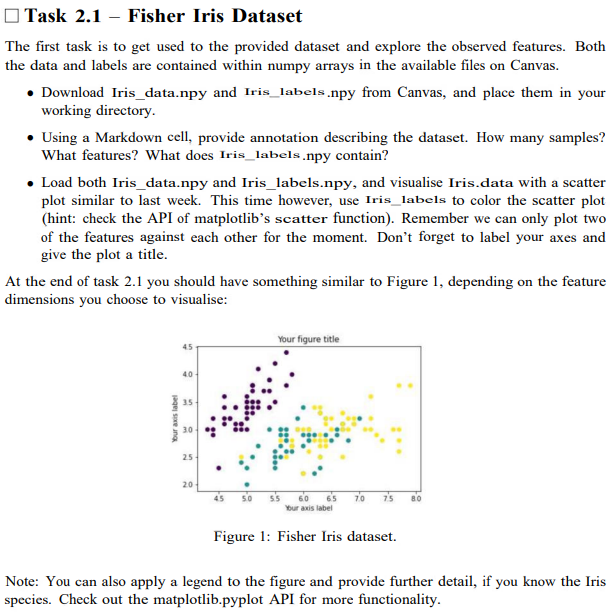

In [ ]:
print(irisLabels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


**In the iris data set,**


---


* there are 4 features
* 3 different classes
* 150 samples

---

* The Iris_data.npy has all the samples.
* The Iris_labels.npy has the class numbers to which the flower belongs to


---





**Code flow**:


```
Step 0: Make sure all the necessary imports and datasets have been loaded
Step 1: Load each individual feature into a new variable
Step 2: Using Matplotlib library, generate the necessary subplots
Step 4: Plot the graph in each supbplot, followed by adding metadata(Axis,
        labels, title, legend, etc)
Step 5: Based on the output, ajust params like figure size and legend  
        position and other visualization changes as per requirements
```



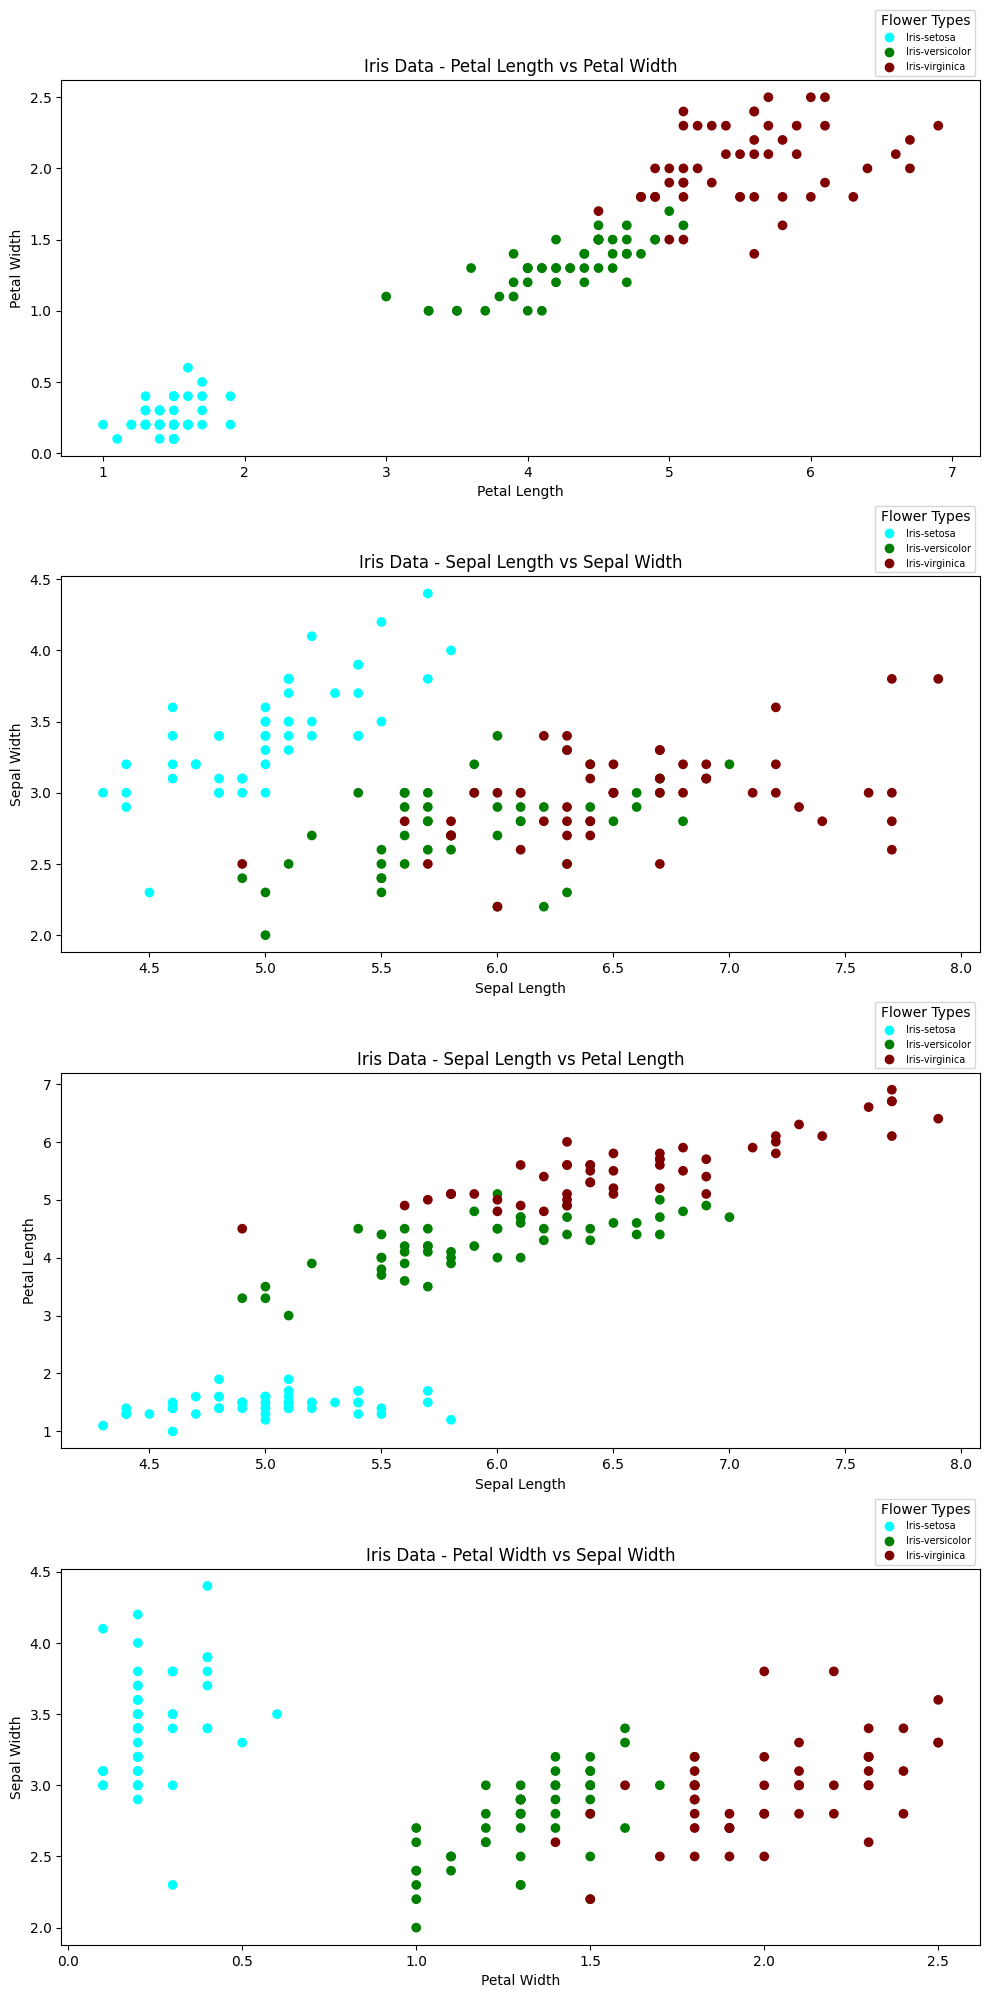

In [ ]:
plt.ion()

#Intializing colrous for different classes
colors = ["cyan", "green", "maroon"]
flower_types= ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

"""
-> Subplots create a sigle figure withh all the graph in it
-> Using figsize param - We can icrease the size of the figure based on our
   dimensional requirements

-> plt.subplots returns two objects: a Figure object and an array of Axes objects
   (or a single Axes object if only one subplot is created).

-> Figure represents the entire figure or canvas containing the subplots.
   It provides a container for the Axes and can be thought of as the overarching
   window or frame.

-> Axes represents a single subplot within the figure.
   It's where you draw the actual plots (lines, bars, scatter points, etc.)
   and includes methods for customizing the subplot (axis limits, labels, etc.).
"""

"""
-> To generate multiple subpots and set a custome figure size to acomodate all
   graphs in a single figure
"""
figure, axes= plt.subplots(4, figsize=(10, 20))


#Graph to show the relation between -> Petal Length vs Petal Width
axes[0].scatter(
                petalLength,
                petalWidth,
                c = [colors[x] for x in irisLabels]
               )
#Set axis labels and graph title
axes[0].set_xlabel("Petal Length")
axes[0].set_ylabel("Petal Width")
axes[0].set_title("Iris Data - Petal Length vs Petal Width")

#Graph to show the relation between -> Sepal Length vs Sepal Width
axes[1].scatter(
                sepalLength,
                sepalWidth,
                c = [colors[x] for x in irisLabels]
               )
#Set axis labels and graph title
axes[1].set_xlabel("Sepal Length")
axes[1].set_ylabel("Sepal Width")
axes[1].set_title("Iris Data - Sepal Length vs Sepal Width")

#Graph to show the relation between -> Sepal Length vs Petal Length
axes[2].scatter(
                sepalLength,
                petalLength,
                c = [colors[x] for x in irisLabels]
                )
#Set axis labels and graph title
axes[2].set_xlabel("Sepal Length")
axes[2].set_ylabel("Petal Length")
axes[2].set_title("Iris Data - Sepal Length vs Petal Length")

#Graph to show the relation between -> Petal Width vs Sepal Width
axes[3].scatter(
                petalWidth,
                sepalWidth,
                c = [colors[x] for x in irisLabels]
               )
#Set axis labels and graph title
axes[3].set_xlabel("Petal Width")
axes[3].set_ylabel("Sepal Width")
axes[3].set_title("Iris Data - Petal Width vs Sepal Width")

#Display the legend for each graph
for subplot_count in range(4):
  #The legend table for each graph
  for i, color in enumerate(colors):
    axes[subplot_count].plot(
                              [],
                              [],
                              marker = "o",
                              color=color,
                              ls='',
                              label=flower_types[i]
                              )
  """
  -> bbox_to_anchor is an optional argument for the legend() function that
     allows for fine-grained control over the legend's position.
  -> loc is a optional arg for legend to place the legend in the pre-defined
     locations provided by the library
  """
  axes[subplot_count].legend(
                              loc='upper right',
                              title='Flower Types',
                              fontsize='x-small',
                              bbox_to_anchor=(1, 1.2)
                            )

#To customizer the graph border so they dont overlap
"""
-> Automatic Adjustment: It automatically adjusts subplot parameters to prevent
   overlapping elements. It tries to find the optimal layout without requiring
   specific input from the user.
"""
plt.tight_layout()

"""
-> Manual Adjustment: It provides more fine-grained control over subplot
   spacing. You can specify the vertical (hspace) and horizontal (wspace)
   spacing between subplots.
"""
#plt.subplots_adjust(hspace=0.5, wspace=0.5)


plt.show()

# Task 2.2

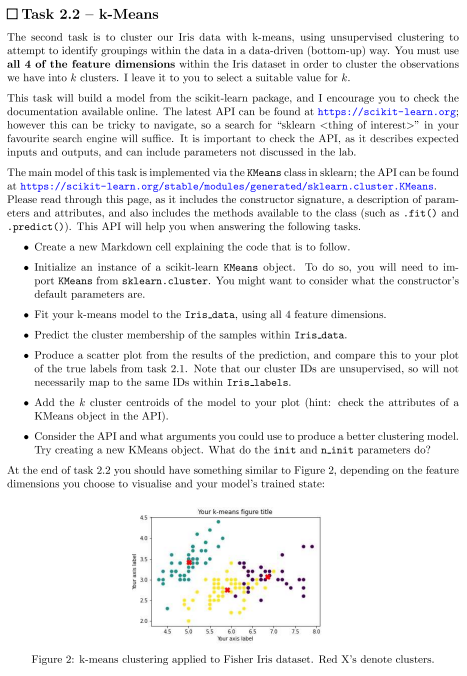

**Notes**


```
init -> * This allows us to use the alternate form of kmeans i.e., kmeans++ or
          random.
        * default is kmeans++
        * random - chosing n differnt points from data, where n is no of
          clusters
        * kmeans++ - gready kmeans algo.

n_init -> * ‘auto’ or int, default=’auto’
          * Number of times the k-means algorithm is run with different centroid seeds
```



## Understanding Kmeans

In [ ]:

X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
kmeans.labels_
kmeans.predict([[5, 5], [0, 5]])
kmeans.cluster_centers_

array([[10.,  2.],
       [ 1.,  2.]])

In [ ]:

X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
kmeans.labels_
kmeans.predict([[5, 5], [0, 5]])
kmeans.cluster_centers_

array([[10.,  2.],
       [ 1.,  2.]])

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans.fit(irisData)
kmeans.labels_
kmeans.predict([[5, 5, 1, 1], [0, 5,2,3]])
print(kmeans.cluster_centers_[0])

[5.00566038 3.36037736 1.56226415 0.28867925]


##Task



```
Step 0: Make sure all the necessary imports and datasets have been loaded
Step 1: Make a copy of original data to work on.
Step 2: Load each individual feature into a new variable
Step 3: Using the KMeans from scikit library, train the algorithm to cluster   
        for the dats using .fit() method
Step 4: Using .labels_ and .cluster_ceneters_ get the cluster labels and the  
        centeroids of the clusters.
Step 5: Using this data, we can predict the upcoming test_data to a specific
        cluster by using .predict()
Step 6: Plot the graphs and visualizations as per requirements

```


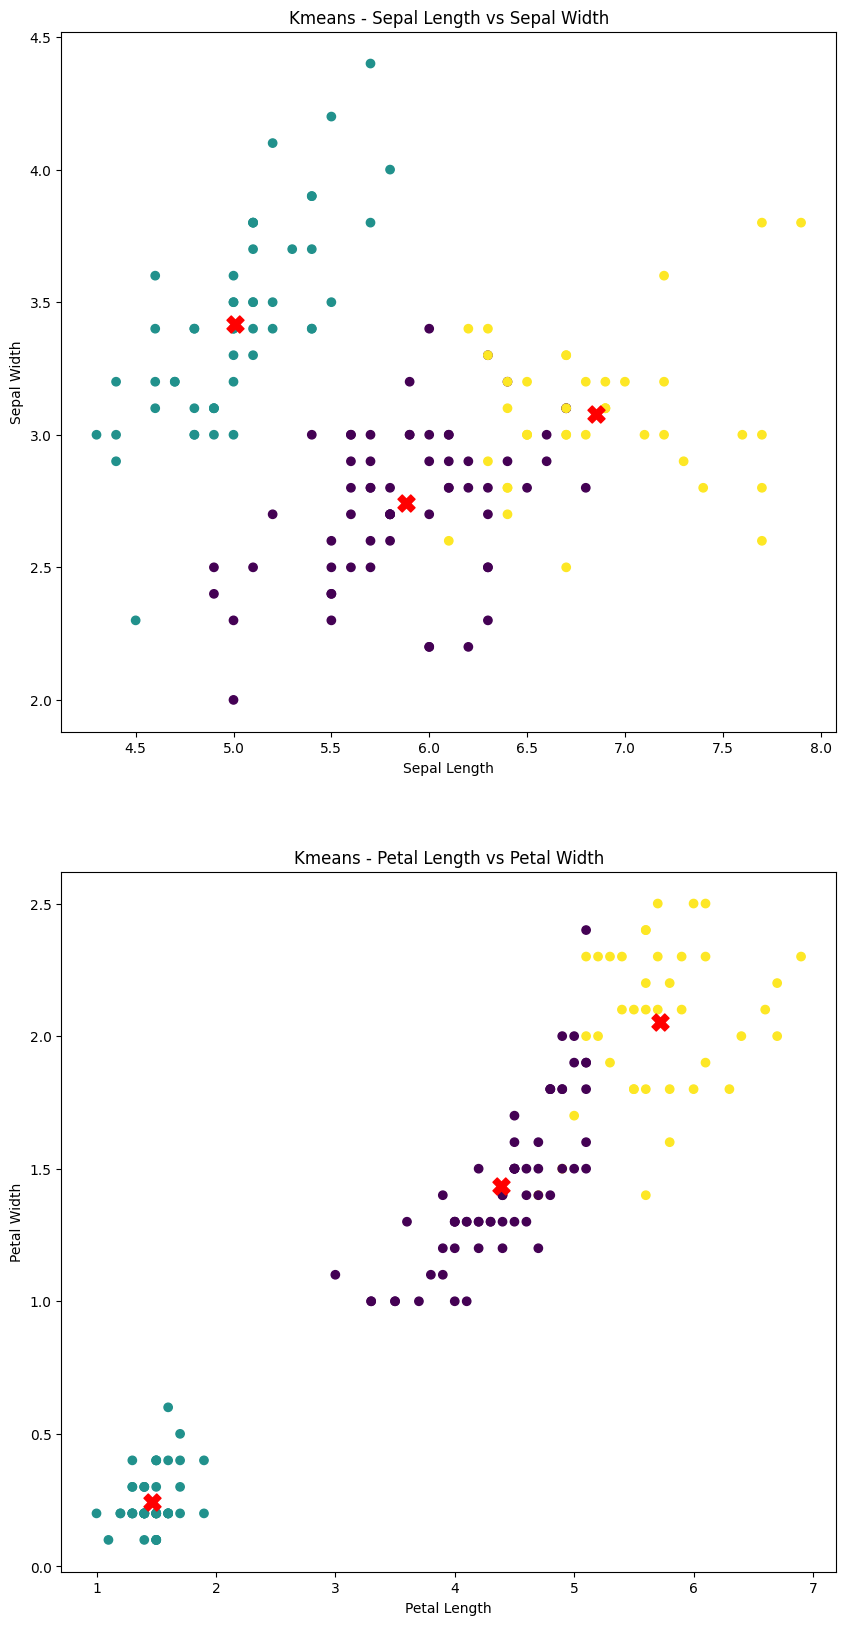

In [ ]:
irisData_Copy = irisData.copy()

#Have the dimensional data as individual variables
sepalLength = [i[0] for i in irisData_Copy]
sepalWidth = [i[1] for i in irisData_Copy]
petalLength = [i[2] for i in irisData_Copy]
petalWidth = [i[3] for i in irisData_Copy]

def generate_graph(labels, centers, clusterCount):
  plt.ion()

  figure, axes = plt.subplots(2, figsize=(10, 20))
  axes[0].scatter(sepalLength, sepalWidth, c=labels)

  for i in centers:
     axes[0].scatter(i[0], i[1], color="red", marker="X", s=150)

  axes[0].set_title('Kmeans - Sepal Length vs Sepal Width')
  axes[0].set_xlabel('Sepal Length')
  axes[0].set_ylabel('Sepal Width')


  #Petal length vs Petal width
  axes[1].scatter(petalLength, petalWidth, c=labels)

  for i in centers:
     axes[1].scatter(i[2], i[3], color="red", marker="X", s=150)

  axes[1].set_title('Kmeans - Petal Length vs Petal Width')
  axes[1].set_xlabel('Petal Length')
  axes[1].set_ylabel('Petal Width')


kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")
kmeans.fit(irisData_Copy)
generate_graph(kmeans.labels_, kmeans.cluster_centers_, 3)

In [ ]:
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

# Task 2.3

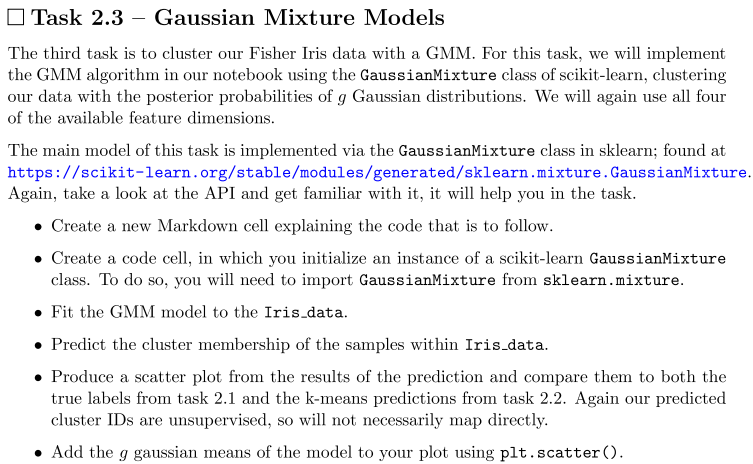

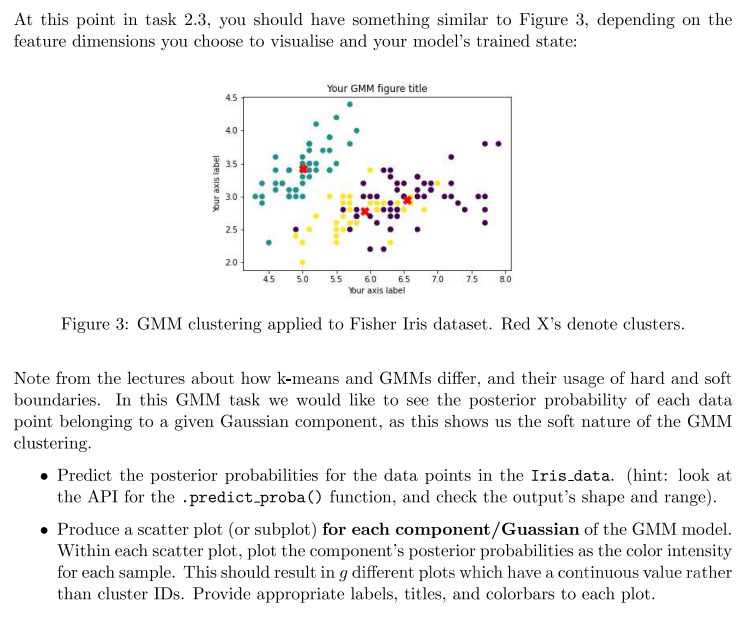


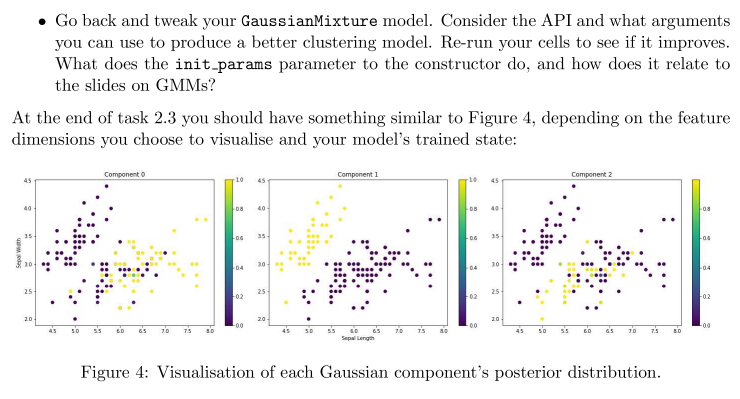

## Understanding GMM

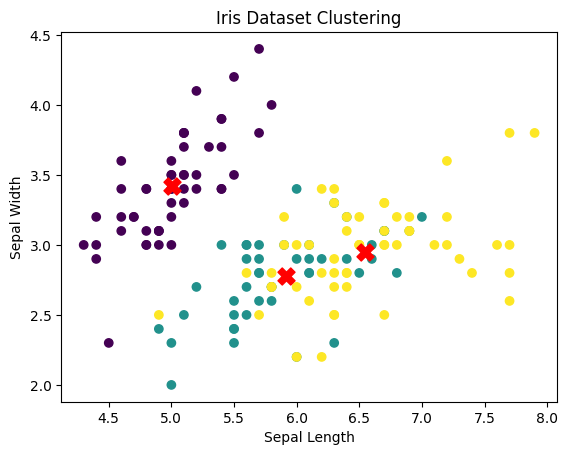

In [ ]:
gmm = GaussianMixture(n_components=3)

gmm.fit(irisData)
labels = gmm.predict(irisData)
cluster_centers = gmm.means_

plt.ion()
plt.scatter(irisData[:, 0], irisData[:, 1], c=labels, cmap='viridis')
plt.title("Iris Dataset Clustering")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

for i in cluster_centers:
    plt.scatter(i[0], i[1], marker='X', color='red', s=150)

plt.show()

## Task


```
Step 0: Make sure all the necessary imports and datasets have been loaded
Step 1: Make a copy of original data to work on.
Step 2: Load each individual feature into a new variable
Step 3: Using the GMM from scikit library, train the algorithm to cluster   
        for the dats using .fit() method
Step 4: Using  gmm.predict(data) and gmm.means_ get the cluster labels and the  
        centeroids of the clusters.
Step 5: Plot the graphs and visualizations as per requirements
```

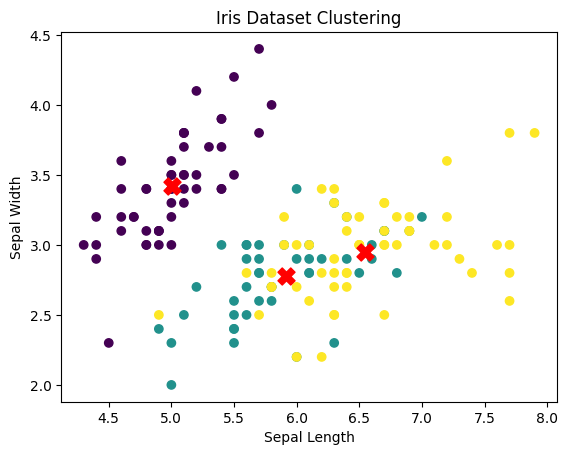

In [ ]:

gmm = GaussianMixture(n_components=3, init_params='k-means++', covariance_type='full',  n_init=5)

gmm.fit(irisData)
labels = gmm.predict(irisData)
cluster_centers = gmm.means_

plt.ion()
plt.scatter(irisData[:, 0], irisData[:, 1], c=labels, cmap='viridis')
plt.title("Iris Dataset Clustering")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

for i in cluster_centers:
    plt.scatter(i[0], i[1], marker='X', color='red', s=150)

plt.show()

In [ ]:
posterior_probabilities = gmm.predict_proba(irisData)
print(posterior_probabilities)

[[1.00000000e+000 7.47881590e-044 7.79289111e-035]
 [1.00000000e+000 6.99297689e-031 2.89107756e-028]
 [1.00000000e+000 8.14194779e-036 5.13554087e-030]
 [1.00000000e+000 1.25980102e-031 3.15117606e-026]
 [1.00000000e+000 2.88301888e-046 3.43836807e-035]
 [1.00000000e+000 6.87964896e-045 3.98832843e-035]
 [1.00000000e+000 7.36020714e-036 7.46659995e-029]
 [1.00000000e+000 4.85504208e-040 7.34321121e-032]
 [1.00000000e+000 1.90436945e-027 3.18995647e-024]
 [1.00000000e+000 1.37279372e-035 9.14087625e-029]
 [1.00000000e+000 2.91084890e-049 7.39314128e-038]
 [1.00000000e+000 1.59755584e-038 3.64583463e-029]
 [1.00000000e+000 8.62103723e-034 2.08429287e-028]
 [1.00000000e+000 4.29040117e-034 9.63340260e-028]
 [1.00000000e+000 3.29329278e-062 5.06304539e-048]
 [1.00000000e+000 1.75848952e-063 1.62225552e-046]
 [1.00000000e+000 3.02742174e-049 3.58242374e-040]
 [1.00000000e+000 2.95213618e-040 9.40290554e-034]
 [1.00000000e+000 1.34694854e-046 5.22090151e-037]
 [1.00000000e+000 2.59044017e-0

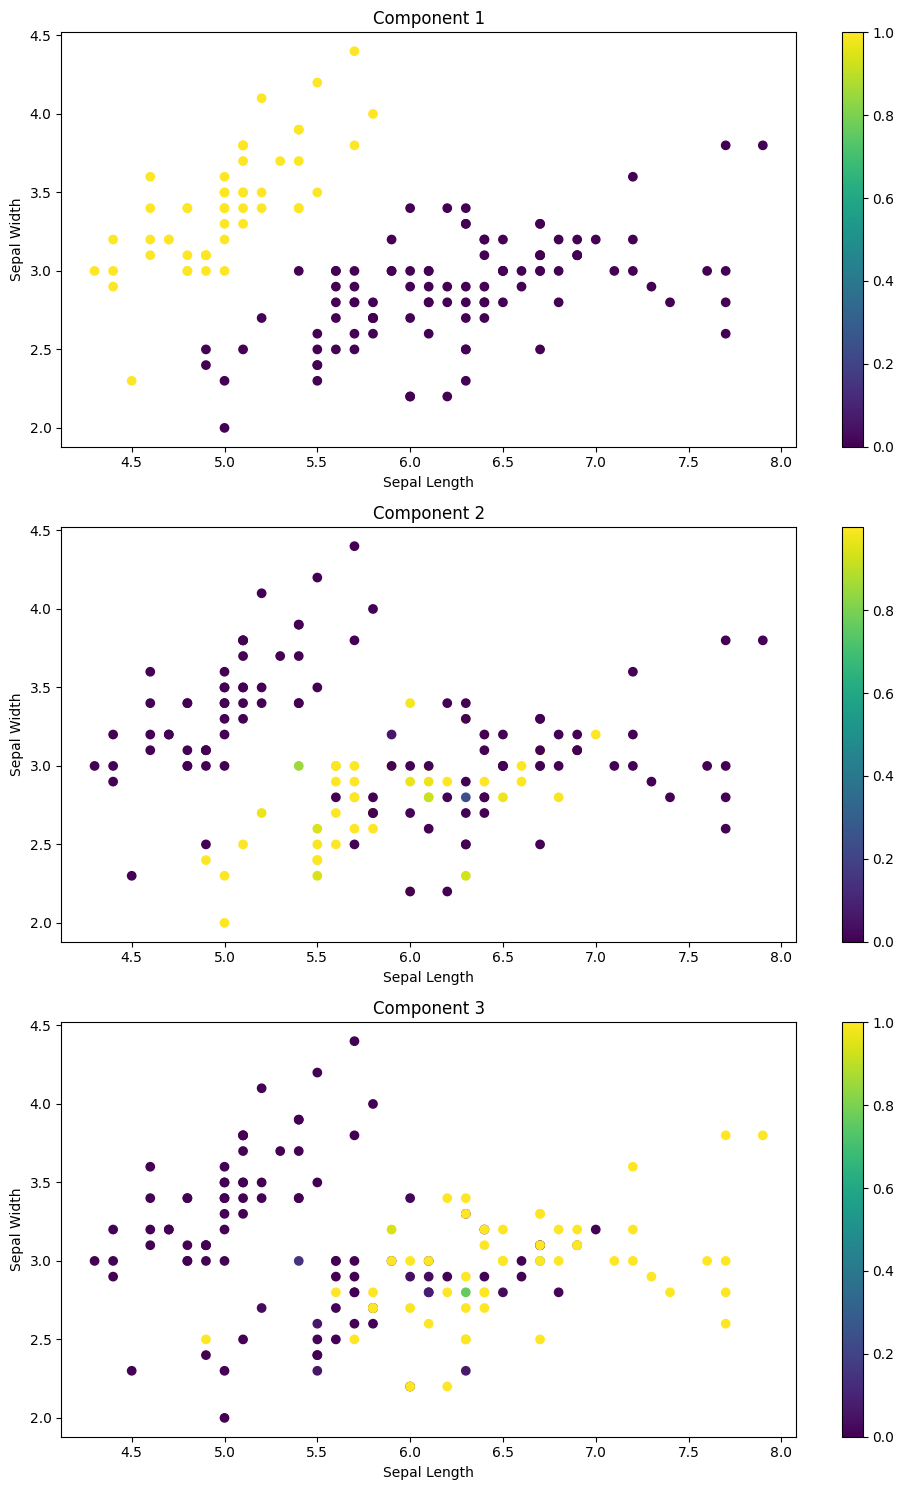

In [ ]:
plt.ion()

figure, axes = plt.subplots(3, figsize=(10, 15))

for i in range(3):
  subplot = axes[i].scatter(
                            irisData[:, 0],
                            irisData[:, 1],
                            c = [probability[i] for probability in posterior_probabilities],
                            cmap = 'viridis'
                           )

  axes[i].set_title(f"Component {i+1}")
  axes[i].set_xlabel("Sepal Length")
  axes[i].set_ylabel("Sepal Width")
  figure.colorbar(subplot)

plt.tight_layout()

plt.show()

#Task 2.4

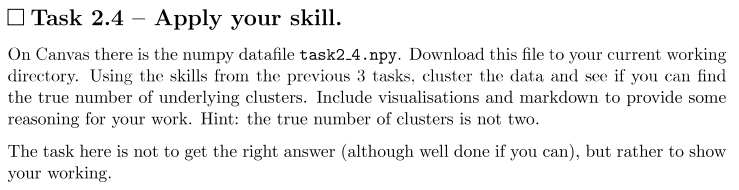

## Understanding Data

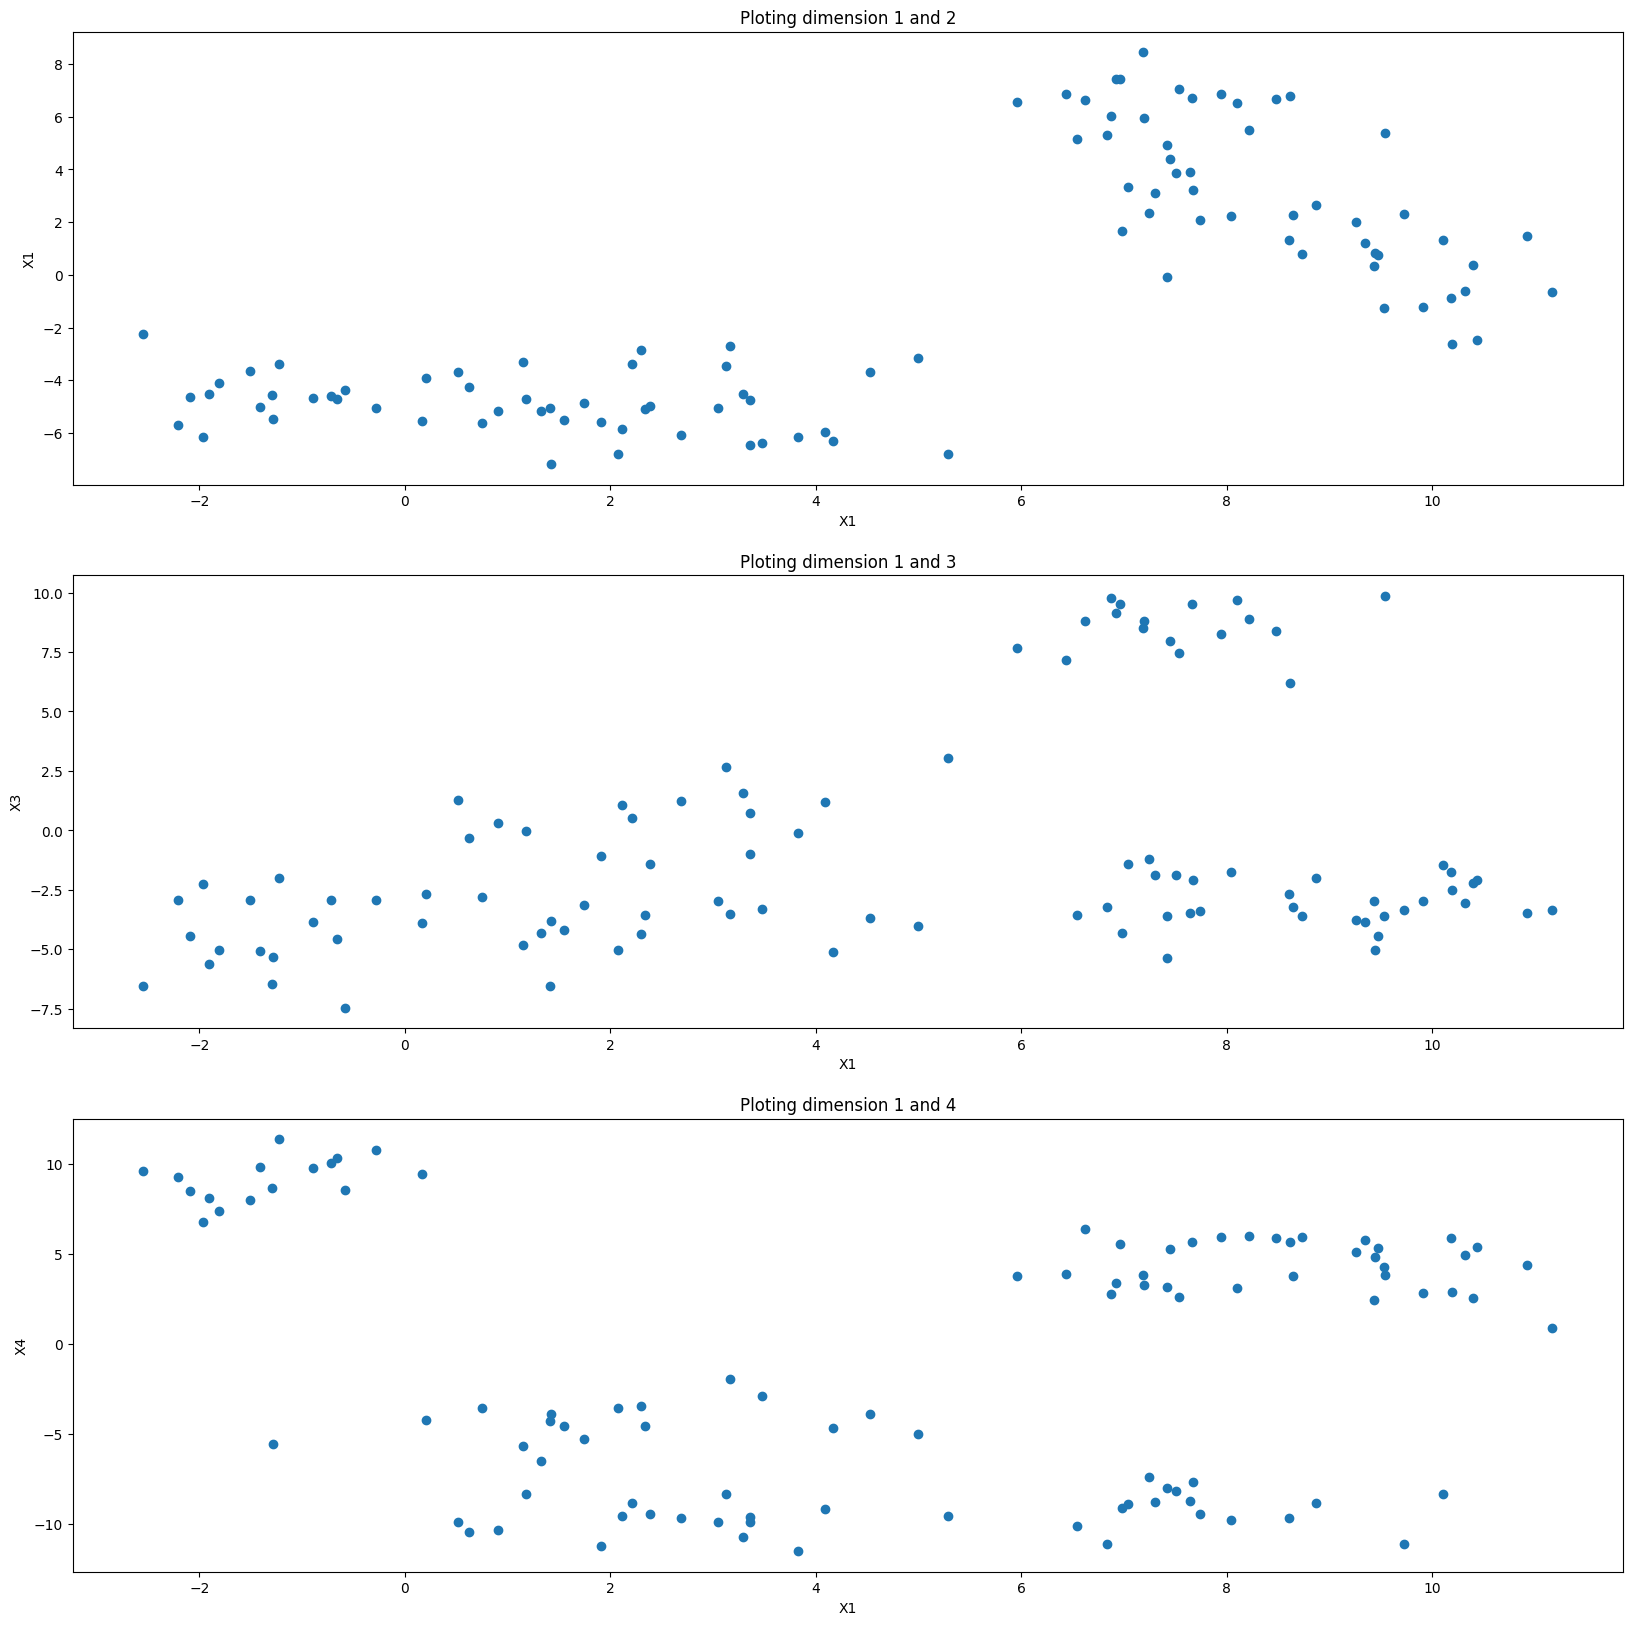

In [ ]:
plt.ion()

figure, axes = plt.subplots(3, figsize=(20,20))

axes[0].scatter(test_data_X1, test_data_X2)
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X1')
axes[0].set_title('Ploting dimension 1 and 2')

axes[1].scatter(test_data_X1, test_data_X3)
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X3')
axes[1].set_title('Ploting dimension 1 and 3')

axes[2].scatter(test_data_X1, test_data_X4)
axes[2].set_xlabel('X1')
axes[2].set_ylabel('X4')
axes[2].set_title('Ploting dimension 1 and 4')

plt.show()

## Finding optimum number of clusters

###Solution 1 - Elbow method

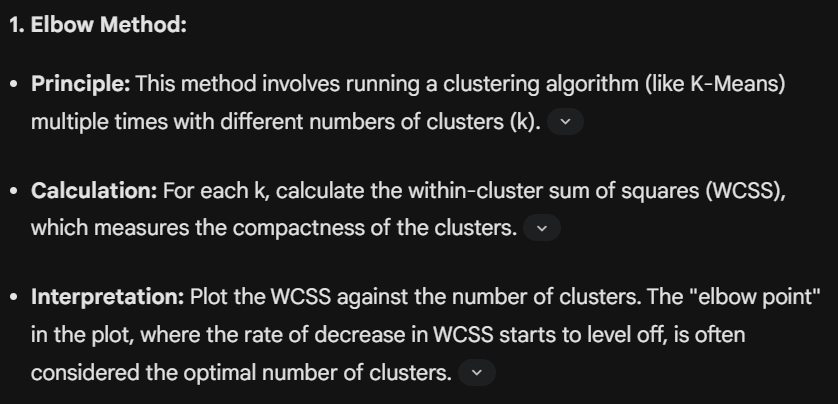

Additional information on Elbow method

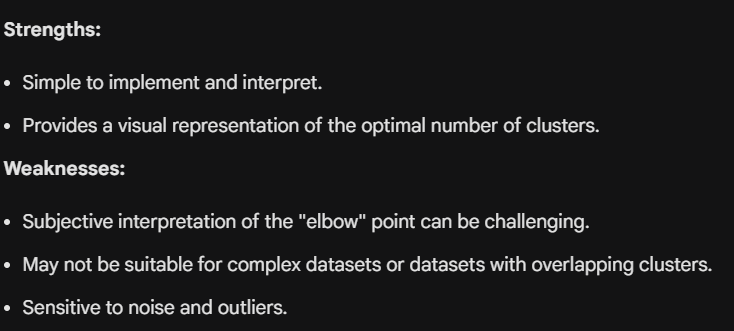

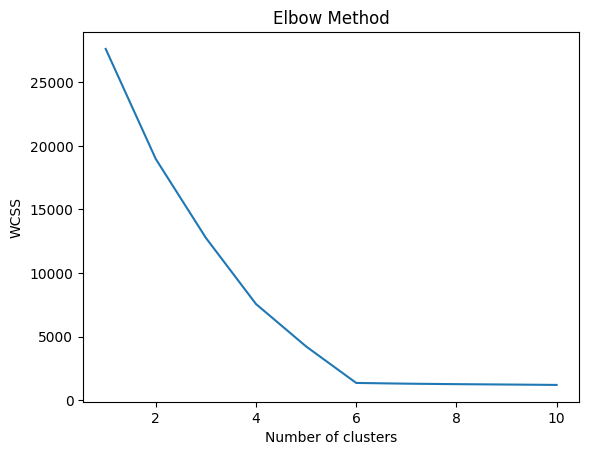

In [ ]:
# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(
                    n_clusters = i,
                    init = 'k-means++',
                    max_iter = 300,
                    n_init = 10,
                    random_state = 0
                   )
    kmeans.fit(test_data2_4)
    wcss.append(kmeans.inertia_)

# Plot the results
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Checking elbow for iris data

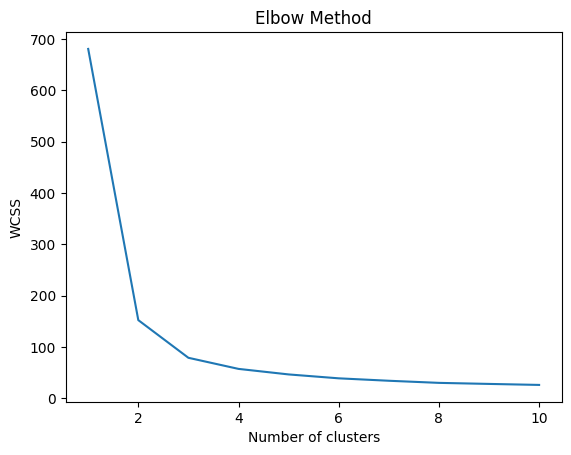

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(irisData)
    wcss.append(kmeans.inertia_)

# Plot the results
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### Solution 2 - Silhouette Analysis

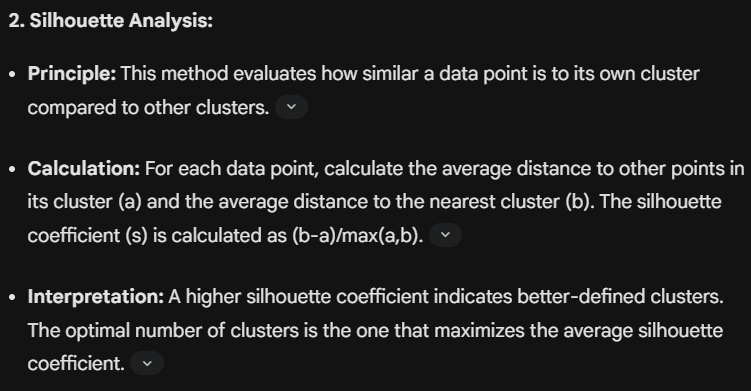

Additional information on Silhouette Analysis

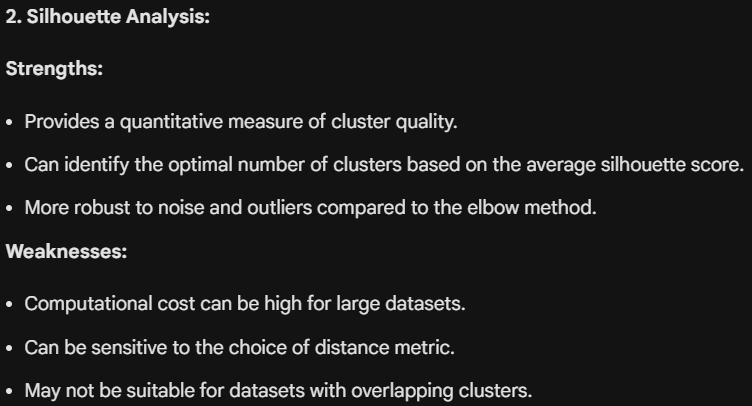

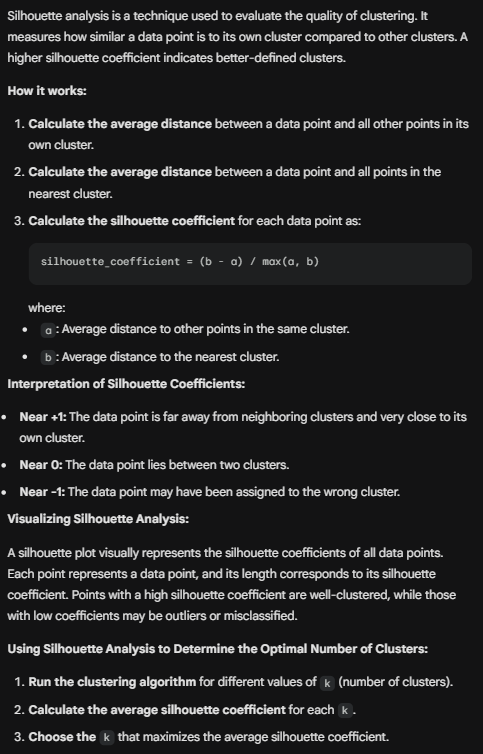

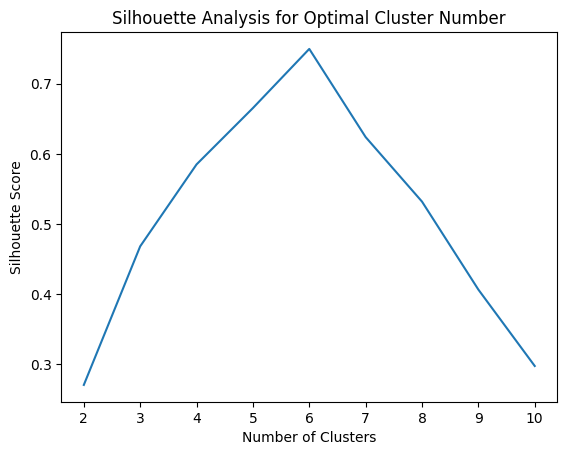

In [ ]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(test_data2_4)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(test_data2_4, labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette scores
plt.plot(range(2, 11), silhouette_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal Cluster Number")
plt.show()

Checking silhoutte analysis scores for iris data

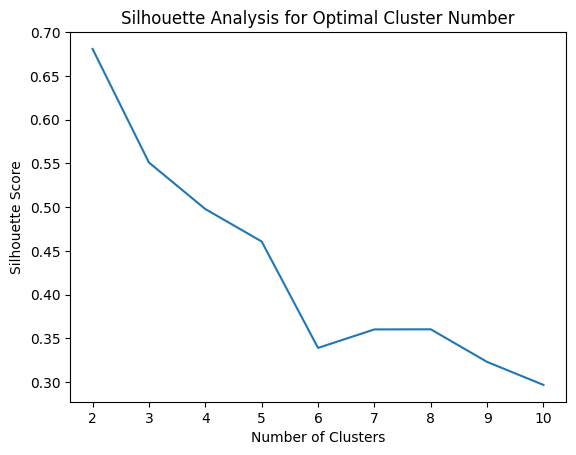

In [ ]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(irisData)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(irisData, labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette scores
plt.plot(range(2, 11), silhouette_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Optimal Cluster Number")
plt.show()

### Summarization

* Inference from graphs generated by **Elbow method** and **Silhouette Analysis** we can conclude that the optimum number of clusters are 6. Hence, for the plots continuing further for this data the cluster count will be considered as 6

## GMM plot

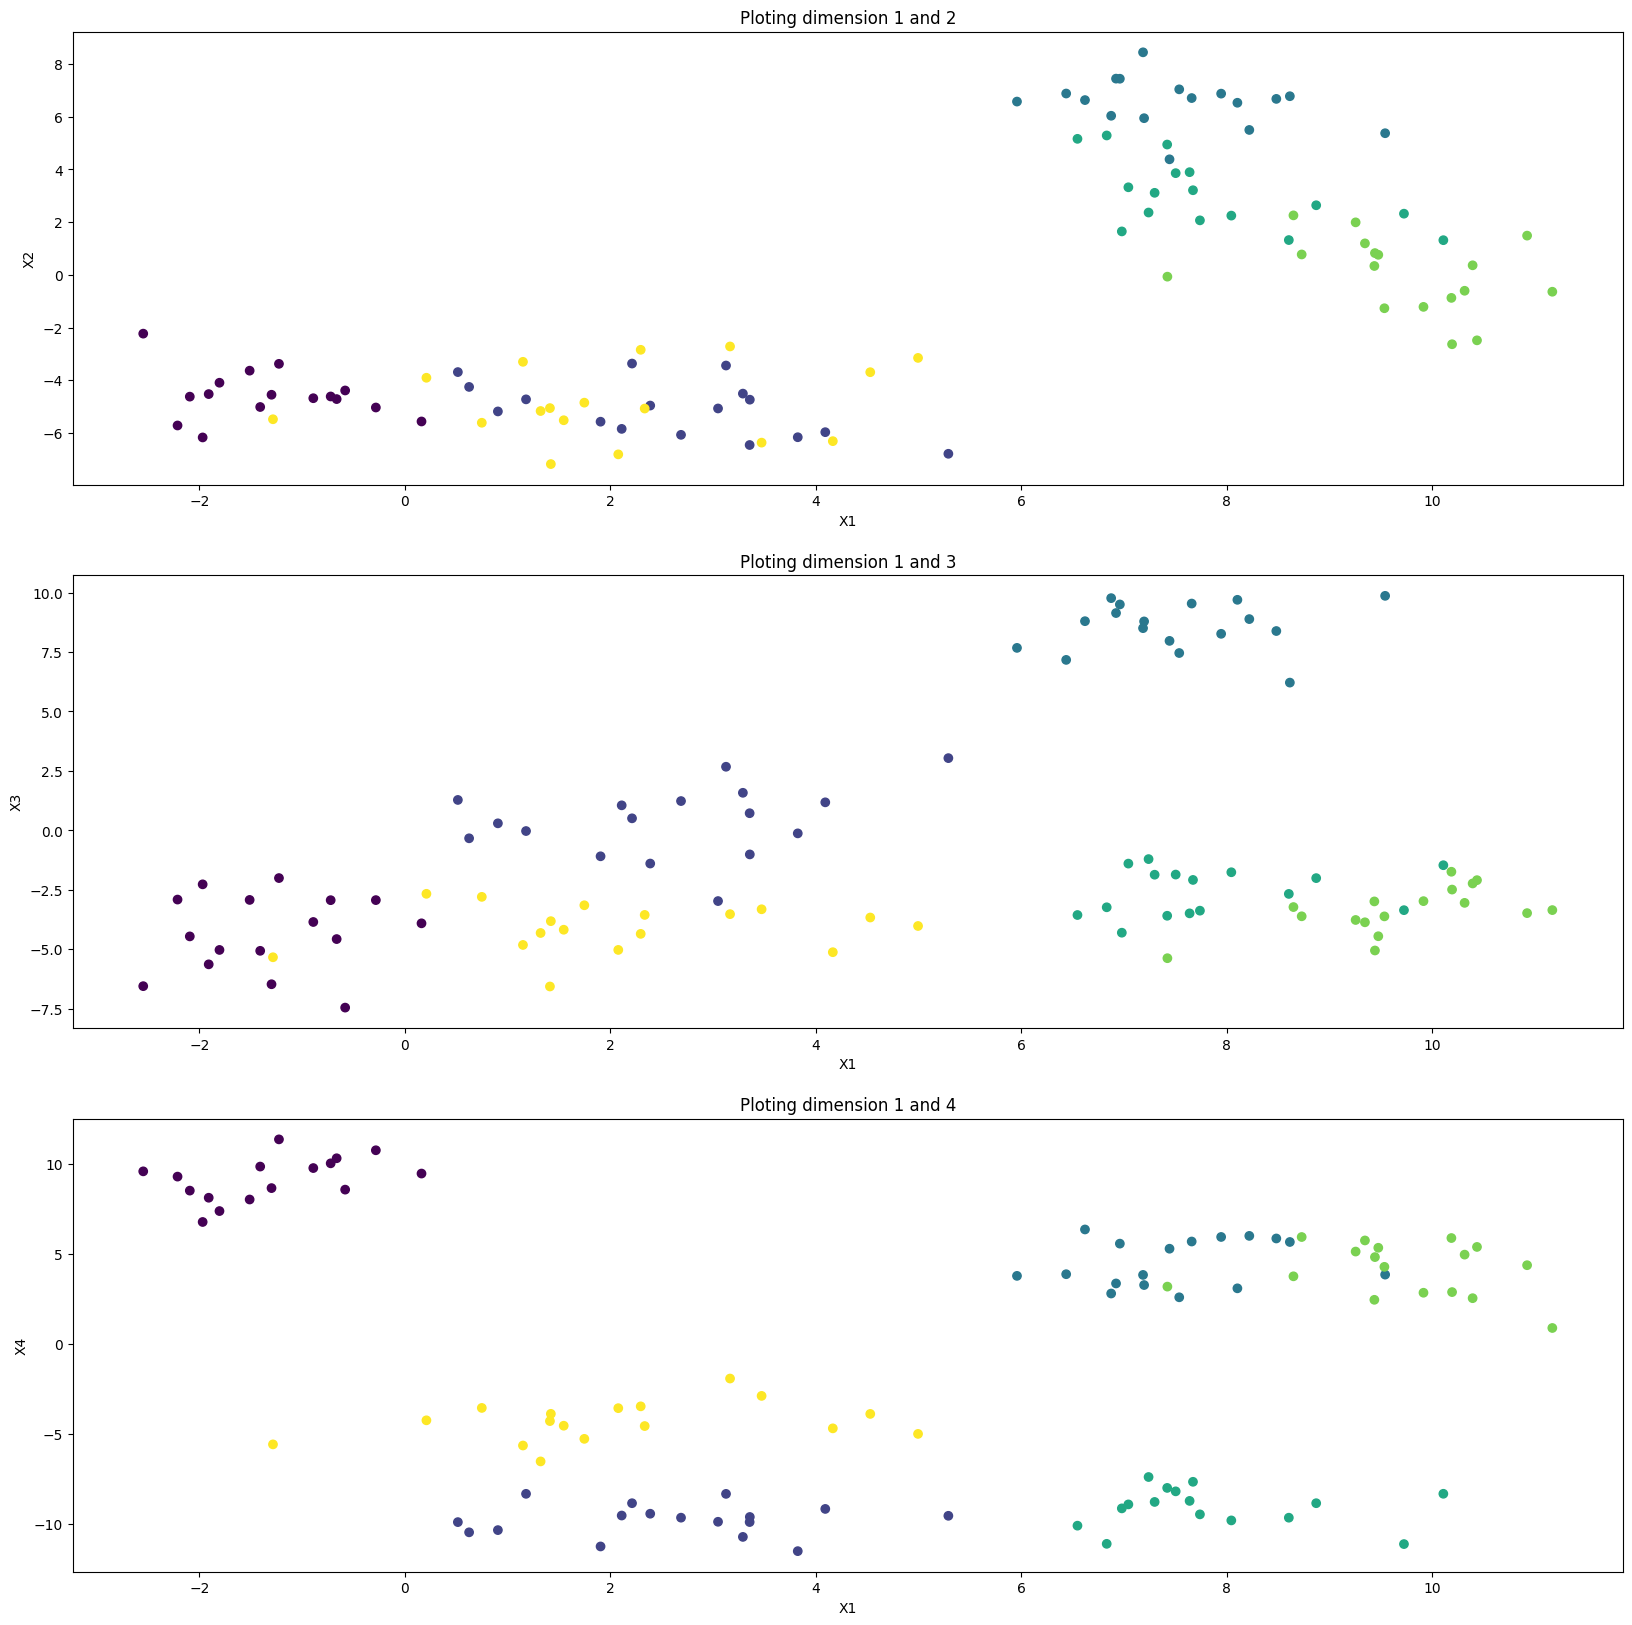

In [ ]:
gmm = GaussianMixture(n_components=6)

gmm.fit(test_data2_4)
labels = gmm.predict(test_data2_4)
cluster_centers = gmm.means_

plt.ion()

figure, axes = plt.subplots(3, figsize=(20,20))

axes[0].scatter(test_data_X1, test_data_X2, c=labels, cmap='viridis')
axes[0].set_xlabel('X1')
axes[0].set_ylabel('X2')
axes[0].set_title('Ploting dimension 1 and 2')

axes[1].scatter(test_data_X1, test_data_X3, c=labels, cmap='viridis')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X3')
axes[1].set_title('Ploting dimension 1 and 3')

axes[2].scatter(test_data_X1, test_data_X4, c=labels, cmap='viridis')
axes[2].set_xlabel('X1')
axes[2].set_ylabel('X4')
axes[2].set_title('Ploting dimension 1 and 4')

plt.show()

plt.show()